# Аналіз відкритих даних Airbnb у Нью-Йорку (США) за 2019 рік

Нью-Йорк (NYC) — одне з найвідоміших і найвідвідуваніших міст у світі. Сюди приїжджають туристи, бізнесмени та шукачі відпочинку, кожен із власною метою. Чимало гостей обирають орендувати житло через платформу Airbnb для тимчасового перебування в місті. Представлені дані відображають активність і показники оголошень на цій платформі в Нью-Йорку за 2019 рік.

**Мета** полягає у проведенні дослідження та візуалізації набору даних за допомогою Python для виявлення ключових закономірностей у ціноутворенні, популярності районів та поведінці орендодавців.

In [1]:
# Імпортуємо потрібні бібліотеки
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Налаштовуємо відображення даних
pd.set_option('display.max_columns', None)

In [2]:
# Завантаження даних
df = pd.read_csv('AB_NYC_2019.csv')

####Підготовка даних до аналізу

**0. Перший погляд на дані**

In [3]:
# Розмір датасету
print(f"Розмір датасету: {df.shape[0]:,} рядків та {df.shape[1]:,} стовпців")

Розмір датасету: 48,895 рядків та 16 стовпців


In [4]:
# Датасет
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [5]:
# Типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

 Опис колонок датасету:

- **id**: id оголошення
- **name**: назва оголошення на сайті
- **host_id**: id орендодавця
- **host_name**: ім'я орендодавця
- **neighbourhood_group**: район Нью-Йорка
- **neighbourhood**: мікрорайон Нью-Йорка
- **latitude**: географічна широта об'єкта
- **longitude**: географічна довгота об'єкта
- **room_type**: тип житла (Entire home/apt — ціле житло, Private room — окрема кімната, Shared room — спільна кімната)
- **price**: ціна оренди за 1 ніч (USD)
- **minimum_nights**: мінімальна кількість ночей
- **number_of_reviews**: загальна кількість відгуків
- **last_review**: дата останнього залишеного відгуку
- **reviews_per_month**: кількість відгуків на місяць
- **calculated_host_listings_count**: кількість усіх об'єктів, які цей орендодавець здає в оренду в Нью-Йорку
- **availability_365**: кількість днів у році, коли житло доступне для бронювання   

In [6]:
# Перевірка пропущених значень
missing_data = df.isnull().sum()
missing_data

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Пропущенні значення є у колонках: name, host_name, last_review, reviews_per_month. Пропущенні значення  заповнимо текстом "Unknown" в колонках name, host_name, last_review та 0 в колонці reviews_per_month.

In [7]:
# Заповнення пропусків в колонці name текстом "Unknown"
df['name'] = df['name'].fillna('Unknown')

In [8]:
# Заповнення пропусків в колонці host_name текстом "Unknown"
df['host_name'] = df['host_name'].fillna('Unknown')

In [9]:
# Заповнення пропусків в колонці last_review текстом "Unknown"
df['last_review'] = df['last_review'].fillna('Unknown')

In [10]:
# Заповнення пропусків в колонці reviews_per_month нулем
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [11]:
# Повторна перевірка пропущених значень
missing_data_re = df.isnull().sum()
missing_data_re

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


Усі пропуски заповнені. Пропущені значення у датасеті відсутні.

In [12]:
# Перевірка наявності нульової ціни
price_null = df['price'].value_counts().sort_index(ascending=True)
price_null

,count
price,
0,11
10,17
11,3
12,4
13,1
...,...
7703,1
8000,1
8500,1


В 11 оголошеннях вказана ціна, що дорівнює 0. Вважатимемо це технічною помилкою або неактуальним оголошенням і видалимо ці рядки.

In [13]:
# Видалення рядків, де ціна дорівнює 0
df = df[df['price'] > 0]

In [14]:
# Повторна перевірка наявності нульової ціни
price_null_re = df['price'].value_counts().sort_index(ascending=True)
price_null_re

,count
price,
10,17
11,3
12,4
13,1
15,6
...,...
7703,1
8000,1
8500,1


In [15]:
# Розмір датасету
print(f"Розмір датасету: {df.shape[0]:,} рядків та {df.shape[1]:,} стовпців")

Розмір датасету: 48,884 рядків та 16 стовпців


Оголошення з ціною, що дорівнює 0, видалені.

In [16]:
# Перевірка дубльованих значень
df[df.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365


Дубльовані значення відсутні.

In [17]:
# Статистика по числовим змінним
stat_columns = ['price', 'minimum_nights',
                'number_of_reviews', 'reviews_per_month',
                'calculated_host_listings_count', 'availability_365']
stats = df[stat_columns].describe()
stats.round(2)

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48884.00,48884.00,48884.00,48884.00,48884.00,48884.00
mean,152.76,7.03,23.27,1.09,7.14,112.78
std,240.17,20.51,44.55,1.60,32.96,131.63
min,10.00,1.00,0.00,0.00,1.00,0.00
25%,69.00,1.00,1.00,0.04,1.00,0.00
50%,106.00,3.00,5.00,0.37,1.00,45.00
75%,175.00,5.00,24.00,1.58,2.00,227.00
max,10000.00,1250.00,629.00,58.50,327.00,365.00


**Висновок:**
- price: Середня ціна становить приблизно 153 USD. Водночас більшість, тобто 75% цін, зосереджені в діапазоні від 10 USD до 175 USD. Однак після позначки 175 спостерігається значний розкид, адже у проміжку між 175 USD та 10000 USD міститься решта 25% усіх цін. Такий великий розкид значно впливає на підвищення середнього значення ціни.
- minimum_nights: Середнє мінімальне значення кількості ночей становить 7. При цьому 75% мінімальної кількості припадає на інтервал від 1 до 5 ночей. Починаючи з межі після 5 ночей, спостерігається значний розкид даних, адже у проміжку від 5 до 1250 ночей зосереджено лише 25% мінімальної кількості. Такі тривалі періоди можуть бути характерними для унікальних або специфічних оголошень, але також існує ймовірність помилок під час внесення інформації в оголошення.
- number_of_reviews: Середній показник відгуків становить 23. 1/4 всіх оголошень зовсім не має відгуків. Ще одна чверть оголошень має до 5 відгуків. Чверть оголошень накопичила від 5 до 24 відгуків, що свідчить про відносно високу популярність цієї нерухомості. І остання чверть оголошень отримала від 24 до 629 відгуків — це вказує на надзвичайно популярне житло серед орендарів, або ж може свідчити про штучне підвищення популярності деяких оголошень.
- reviews_per_month: Середня кількість відгуків на місяць становить 1. Тобто три чверті оголошень отримують всього 1–2 відгуки щомісяця. Однак 25 % оголошень демонструють значно вищу активність, досягаючи показника до 58 відгуків на місяць. Це може свідчити як про виняткову популярність таких об'єктів нерухомості, так і про можливе дублювання відгуків задля штучного підвищення попиту.
- calculated_host_listings_count: Переважна більшість орендодавців (75%) мають у власності лише 1–2 об’єкти нерухомості, які здають в оренду. Водночас середній показник житла на одну особу становить 7 об’єктів. Такий результат обумовлений значним розкидом у решти 25% власників, на частку яких припадає від 2 до 327 об’єктів. Можливо, управління такою кількістю нерухомості здійснюється рієлторськими агентствами від імені власників.
- availability_365: Середній рівень доступності житла становить близько 113 днів на рік. Умовно всі об'єкти можна поділити на чотири категорії: 25% недоступні для бронювання через постійну зайнятість або деактивовані оголошення, інші 25% пропонуються для бронювання не більше ніж на 45 днів, тобто лише у певні періоди року. Наступна чверть об'єктів має доступність у межах від 45 до 227 днів, що свідчить про помірний рівень доступу протягом року. Решта 25% житла відкриті для бронювань майже цілорічно, забезпечуючи максимальну гнучкість для орендарів.

####Загальна інформація

**1. Яку кількість квартир здають в оренду, кількість орендодавців та загальну кількість відгуків?**

In [18]:
rent_list = df['id'].nunique()
print(f'Кількість квартир, що здаються в оренду: {rent_list}')

Кількість квартир, що здаються в оренду: 48884


In [19]:
host = df['host_id'].nunique()
print(f'Кількість орендодавців, що здають в оренду квартиру: {host}')

Кількість орендодавців, що здають в оренду квартиру: 37455


In [20]:
reviews = df['number_of_reviews'].sum()
print(f'Загальна кількість відгуків: {reviews}')

Загальна кількість відгуків: 1137628


**Висновок:**

Кількість орендодавців є меншою за число квартир, доступних для оренди, що свідчить про можливість володіння кількома об'єктами нерухомості одним власником. Водночас значне перевищення загальної кількості відгуків над числом пропозицій оренди вказує на високу популярність платформи та активний інтерес орендарів, які охоче діляться своїм досвідом.

####Аналіз кількості оголошень оренди

**2. Розподіл житла за типом** (Яка кількість житла кожного типу присутня на сайті?)

In [21]:
count_room_type = df['room_type'].value_counts().sort_values(ascending=False)
count_room_type

,count
room_type,
Entire home/apt,25407
Private room,22319
Shared room,1158


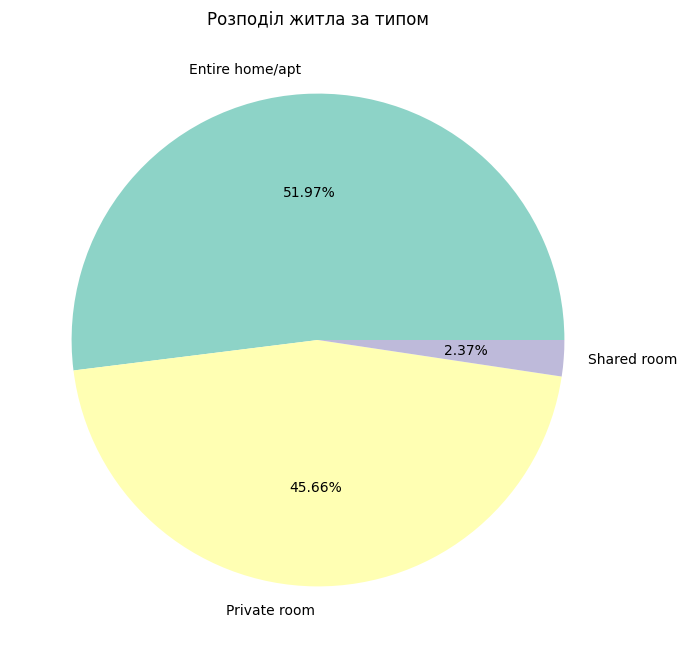

In [22]:
# Візуалізація розподілу
count_room_type.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Entire home/apt', 'Private room', 'Shared room'],
    title='Розподіл житла за типом',
    ylabel='',
    colors=plt.cm.Set3.colors
);

**Висновок:**

Найчастіше здають апартаменти або будинок повністю (ціле житло). Також велика кількість оголошень пропонує до оренди окремі (приватні) кімнати. В той же час кількість пропозицій по оренді спільних кімнат найменша, що означає відсутність популярності серед орендарів до цього типу житла.

*(Entire home/apt — ціле житло, Private room — окрема кімната, Shared room — спільна кімната)*

**3. Розподіл оголошень за районами міста** (В якому районі міста зосореджена найбільша кількість оголошень?)

In [23]:
count_neighbourhood_group = df['neighbourhood_group'].value_counts().sort_values(ascending=False)
count_neighbourhood_group

,count
neighbourhood_group,
Manhattan,21660
Brooklyn,20095
Queens,5666
Bronx,1090
Staten Island,373


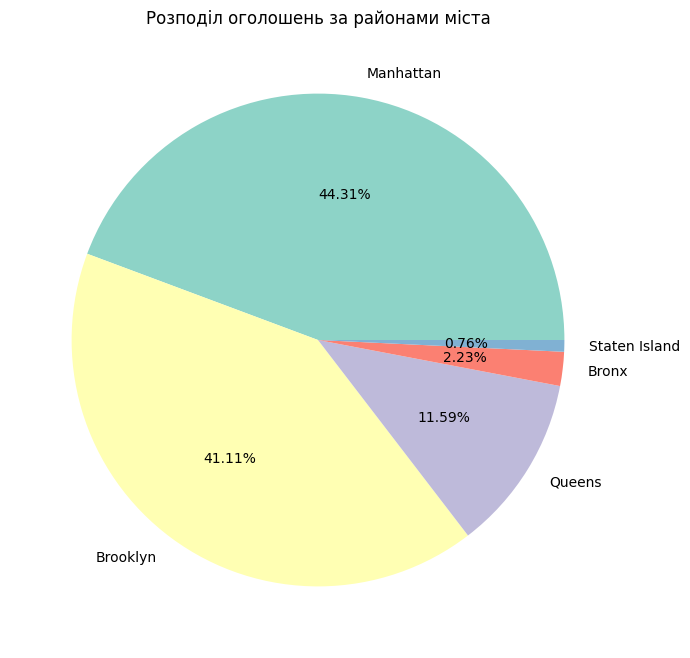

In [24]:
# Візуалізація розподілу
count_neighbourhood_group.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten Island'],
    title='Розподіл оголошень за районами міста',
    ylabel='',
    colors=plt.cm.Set3.colors
);

**Висновок:**

Нерухомість для оренди найчастіше зосереджена в районах Manhattan та Brooklyn, що обумовлено їхньою популярністю серед туристів, а також насиченим діловим і культурним життям. Значно менше оголошень опубліковано для Queens та Bronx, які вирізняються своєю тихішою атмосферою. Район Queens привертає трохи більше уваги через наявність на його території великих аеропортів. Найменш популярним районом є Staten Island, що можна пояснити його віддаленістю та розташуванням на острові.

**4. В яких мікрорайонах найчастіше здають житло в оренду (топ-10)?**

In [25]:
count_neighbourhood = df[['neighbourhood_group', 'neighbourhood']].value_counts().sort_values(ascending=False)
count_neighbourhood.head(10)

neighbourhood_group  neighbourhood     
Brooklyn             Williamsburg          3919
                     Bedford-Stuyvesant    3710
Manhattan            Harlem                2658
Brooklyn             Bushwick              2462
Manhattan            Upper West Side       1971
                     Hell's Kitchen        1958
                     East Village          1853
                     Upper East Side       1798
Brooklyn             Crown Heights         1564
Manhattan            Midtown               1545
Name: count, dtype: int64

**Висновок:**

Популярність районів Manhattan та Brooklyn серед оголошень оренди підтверджується. Не зважаючи на те, що Manhattan має найбільшу сумарну кількість оголошень, Williamsburg та Bedford-Stuyvesant, які знаходяться у Brooklyn, є лідерами за кількістю оголошень серед мікрорайонів міста. Далі йдуть Harlem (Manhattan) та Bushwick (Brooklyn). За ними 4 райони Manhattan (Upper West Side, Hell's Kitchen, East Village, Upper East Side). Далі знову чергуються Brooklyn (Crown Heights) та Manhattan (Midtown).

**5. У кого і в яких районах/мікрорайонах найбільша кількість оголошень оренди (топ-10)?**

In [26]:
host_id_by_neighbourhood = df.groupby(['neighbourhood_group', 'neighbourhood'])['host_id'].value_counts()
host_id_by_neighbourhood.sort_values(ascending=False).head(10)

neighbourhood_group  neighbourhood       host_id  
Manhattan            Financial District  219517861    218
Brooklyn             Greenpoint          7503643       52
Manhattan            Financial District  12243051      51
                     Murray Hill         120762452     50
                                         219517861     50
                     Midtown             205031545     49
                     Hell's Kitchen      190921808     46
                                         30283594      41
                     Chelsea             107434423     37
Queens               Woodside            137358866     35
Name: count, dtype: int64

**Висновок:**

Популярність районів Manhattan та Brooklyn знову підтверджується. Лідером є орендодавець з id 219517861 у мікрорайоні Financial District (Manhattan), який	має найбільшу кількість об'єктів для оренди в місті - 218. Другим за кількістю об'єктів оренди є орендодавець з id 7503643 з Greenpoint (Brooklyn) - 52. Далі йдуть 7 власників з Manhattan (Financial District, Murray Hill, Midtown, Hell's Kitchen, Chelsea), але зауважимо, що мікрорайони дещо відрізняються від перелічених у попередньому питанні. І закриває топ-10 орендодавець з id 137358866 з Woodside (Queens), що показує, що не зважаючи на велику популярність Manhattan та Brooklyn у орендарів, інші райони міста також користуються попитом. Наприкінці можна припустити, що власники з настільки великою кількістю об'єктів імовірно є агентствами, які спеціалізуються на наданні послуг оренди.



####Аналіз ціни

**6. Яка ціна оренди найчастіше зустрічається в оголошеннях (топ-10)?**

In [27]:
count_price = df['price'].value_counts().sort_values(ascending=False)
count_price.head(10)

,count
price,
100,2051
150,2047
50,1534
60,1458
200,1401
75,1370
80,1272
65,1190
70,1170


**Висновок:**

Найбільш популярними цінами в оголошеннях є 100 USD і 150 USD, які займають лідируючі позиції в рейтингу. Їх найближчу конкуренцію складають суми 50 USD, 60 USD і 200 USD. У другій п’ятірці найпоширеніших цін знаходяться 75 USD, 80 USD, 65 USD, 70 USD та 120 USD. Особливу частоту серед пропозицій мають саме цінники в 100 USD і 150 USD. Водночас можна зазначити, що популярні ціни зазвичай потрапляють у доступний діапазон від 50 USD до 80 USD. Завершує десятку найпоширеніших варіантів цінник у розмірі 120 USD. Крім того, можна помітити тенденцію до використання цін, кратних 5 або 10, що робить процес визначення вартості простішим для орендодавців.

**7. Розподіл медіанної ціни за типом житла** (Який тип житла найдорожчий?)

In [28]:
price_by_room_type = df.groupby('room_type')['price'].median().sort_values(ascending=False)
price_by_room_type

,price
room_type,
Entire home/apt,160.0
Private room,70.0
Shared room,45.0


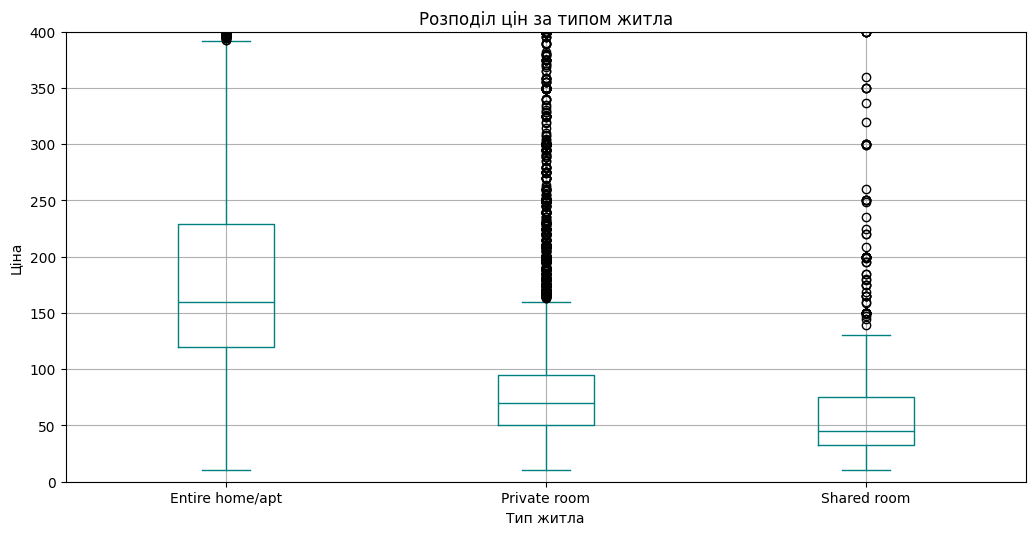

In [29]:
# Візуалізація розподілу
df.boxplot(
    column='price',
    by='room_type',
    figsize=(12, 6),
    grid =True,
    color='teal'
)

plt.title('Розподіл цін за типом житла')
plt.suptitle('')
plt.xlabel('Тип житла')
plt.ylabel('Ціна')

plt.ylim(0, 400)
plt.show()

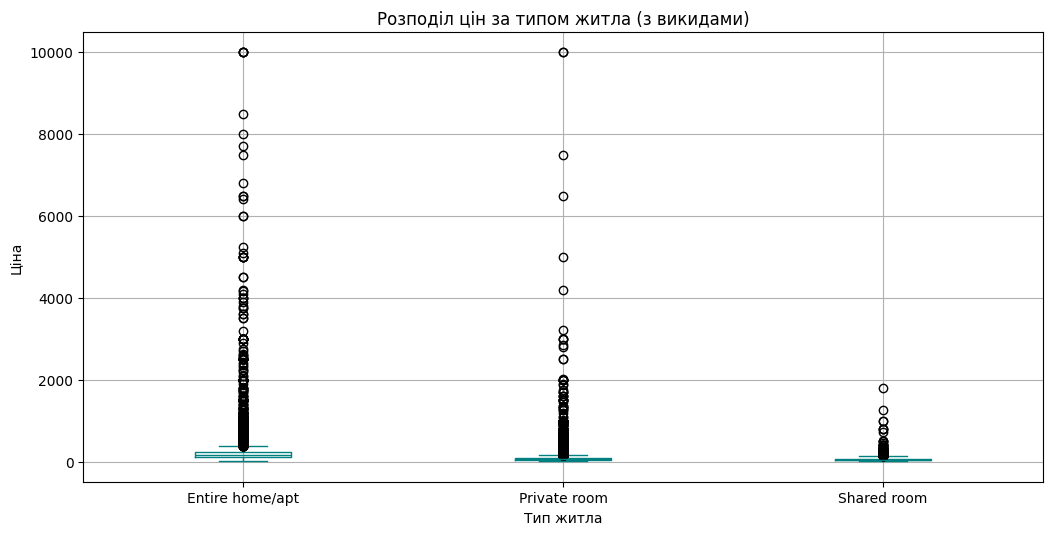

In [30]:
# Візуалізація розподілу (з викидами)
df.boxplot(
    column='price',
    by='room_type',
    figsize=(12, 6),
    grid=True,
    color='teal'
)

plt.title('Розподіл цін за типом житла (з викидами)')
plt.suptitle('')
plt.xlabel('Тип житла')
plt.ylabel('Ціна')

plt.show()

**Висновок:**

Медіанна вартість оренди цілих будинків або апартаментів є найвищою. Оренда окремих (приватних) кімнат майже вдвічі дешевша, що цілком логічно, оскільки оплата здійснюється лише за одну кімнату, а не за весь простір. Найекономнішим варіантом, з огляду на ціну, є спільні кімнати, де вартість однієї кімнати розподіляється між кількома людьми.

На графіку видно, що більшість цін у всіх типах житла зосереджена у межах до 400 USD. Наявна значна кількість викидів — окремих точок, які стосуються категорій цілого житла та приватних кімнат. Це свідчить про наявність у Нью-Йорку сегменту елітної нерухомості з цінами, що в рази перевищують середньоринкові показники. Такі дані ускладнюють застосування середнього арифметичного, тому використання медіани у цьому випадку є більш обґрунтованим для аналізу.

**8. Розподіл медіанної ціни за районами міста** (Який район найдорожчий для оренди?)

In [31]:
price_by_neighbourhood_group = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
price_by_neighbourhood_group

,price
neighbourhood_group,
Manhattan,150.0
Brooklyn,90.0
Queens,75.0
Staten Island,75.0
Bronx,65.0


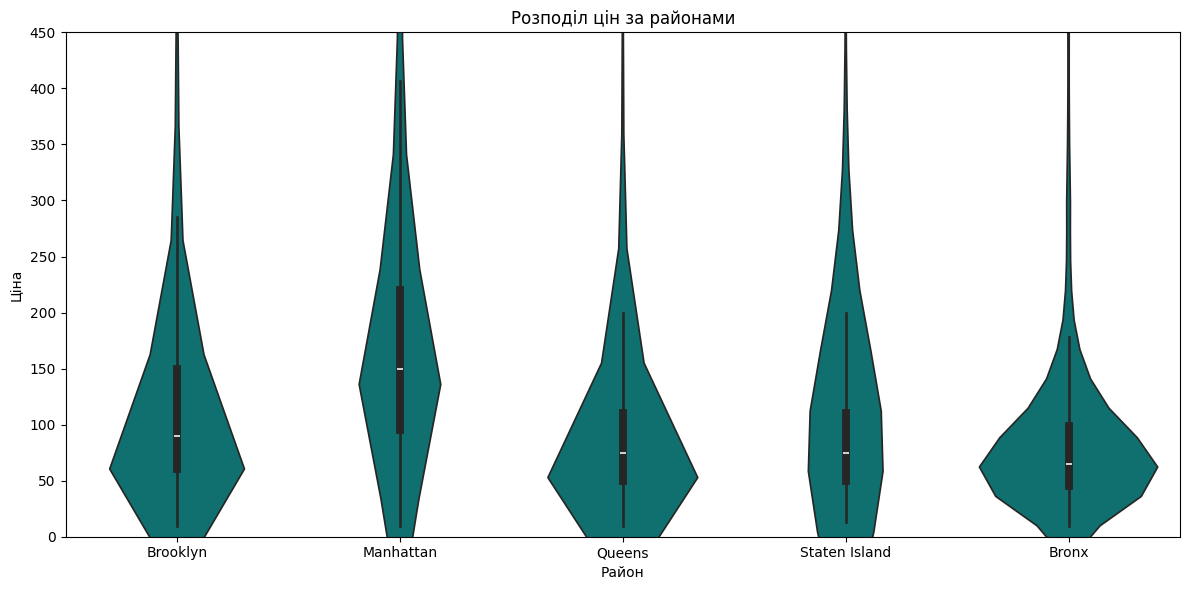

In [32]:
# Візуалізація розподілу
plt.figure(figsize=(12, 6))

sns.violinplot(data=df, x='neighbourhood_group', y='price', color='teal')

plt.title('Розподіл цін за районами')
plt.xlabel('Район')
plt.ylabel('Ціна')

plt.ylim(0, 450)
plt.tight_layout()
plt.show()

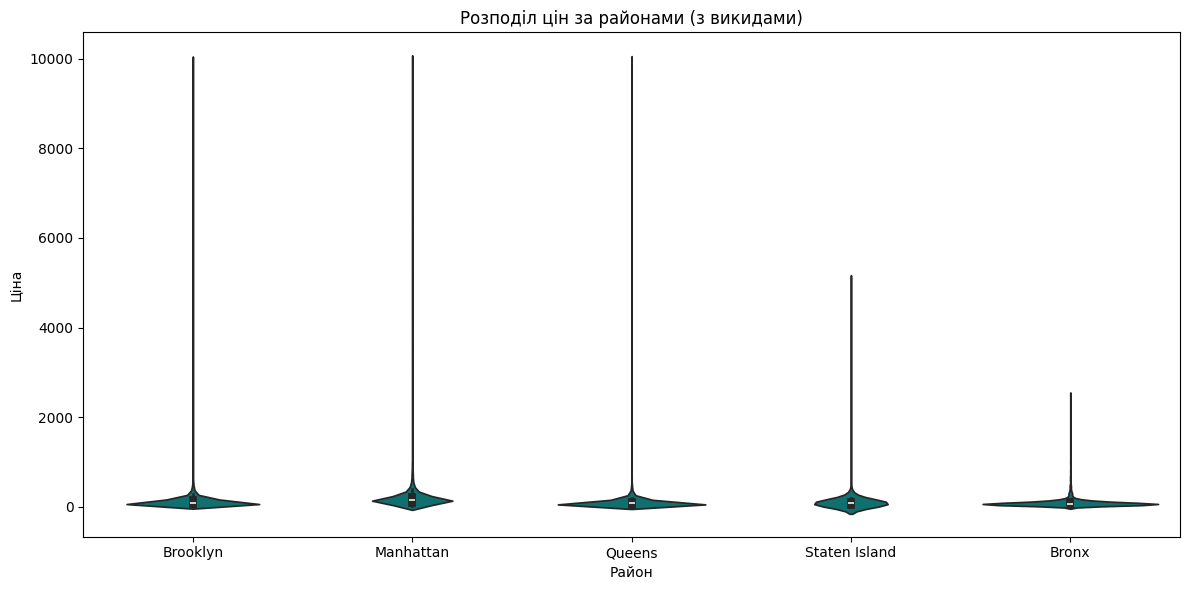

In [33]:
# Візуалізація розподілу (з викидами)
plt.figure(figsize=(12, 6))

sns.violinplot(data=df, x='neighbourhood_group', y='price', color='teal')

plt.title('Розподіл цін за районами (з викидами)')
plt.xlabel('Район')
plt.ylabel('Ціна')

plt.tight_layout()
plt.show()

**Висновок:**

Медіанна вартість оренди найвища у Manhattan. Наступним за вартістю йде
Brooklyn. Queens та Staten Island мають однакову медіанну вартість, не зважаючи на значно меншу кількість оголошень у Staten Island. Bronx має найнижчу медіанну вартість оренди.

На графіку видно, що більшість цін у всіх районах зосереджена у межах до 400 USD. Наявні викиди у районах Brooklyn, Manhattan та Queens. У кожному з цих районів наявне житло вартість якого сягає 10000 USD, скоріше за все це житло відноситься до категорії елітного житла. В Staten Island також наявні викиди. Вартість такої оренди майже вдічі менша (близько 5000 USD), але можна зробити висновок, що категорія елітного житла там також присутня. Найменша кількість викидів у Bronx. Такі ціни-викиди значно перевищують середньоринкові показники, що ускладнює застосування середнього арифметичного, тому використання медіани у цьому випадку є більш обґрунтованим для аналізу.

**9. Розподіл ціни за мікрорайонами міста** (Який мікрорайон є найдорожчим для оренди (топ-10)?)

In [34]:
price_by_neighbourhood = df.groupby(['neighbourhood_group', 'neighbourhood'])['price'].median()
price_by_neighbourhood.sort_values(ascending=False).head(10)

neighbourhood_group  neighbourhood     
Staten Island        Fort Wadsworth        800.0
                     Woodrow               700.0
Manhattan            Tribeca               295.0
Queens               Neponsit              274.0
Manhattan            NoHo                  250.0
Staten Island        Willowbrook           249.0
Manhattan            Flatiron District     225.0
                     Midtown               210.0
                     Financial District    200.0
                     West Village          200.0
Name: price, dtype: float64

**Висновок:**

Не зважаючи на високу популярність та високу медіанну вартість житла в районах Manhattan та Brooklyn, найдорожчими мікрорайонами є Fort Wadsworth та Woodrow, що розташовані на Staten Island. Тобто саме там знаходять одні з найдорожчих об'єктів оренди. Наступним йде мікрорайон Tribeca (Manhattan), але він значно (майже в 2,5 рази) поступається ціною Wadsworth та Woodrow. На 4 місці знаходиться Neponsit (Queens). 5 місце - NoHo (Manhattan). 6 місце - Willowbrook (Staten Island). У підсумковій десятці також знаходяться мікрорайони Manhattan: Flatiron District, Midtown, Financial District, West Village. Цікаво, що жоден із мікрорайонів Brooklyn, який у середньому демонструє другу за величиною медіанну вартість оренди після Manhattan, не потрапив до списку топ-10. Водночас присутність неочевидних мікрорайонів Staten Island та Queens свідчить про те, що саме там можна знайти значну частину елітного житла, представленого для оренди. Але варто врахувати можливий вплив статистичної похибки: у випадку зі Staten Island високі ціни можуть бути зумовлені обмеженою вибіркою даних, наприклад, лише кількома надзвичайно дорогими пропозиціями, тоді як третє місце мікрорайону Tribeca (Manhattan), скоріш за все, ґрунтується на великій кількості об’єктів із стабільно високими цінами.

####Аналіз кількості відгуків

**10. Розподіл типу житла за кількістю відгуків** (Якому типу житла залишають найбільшу кількість відгуків?)

In [35]:
reviews_by_room_type = df.groupby('room_type')['number_of_reviews'].sum()
reviews_by_room_type

,number_of_reviews
room_type,
Entire home/apt,580400
Private room,537979
Shared room,19249


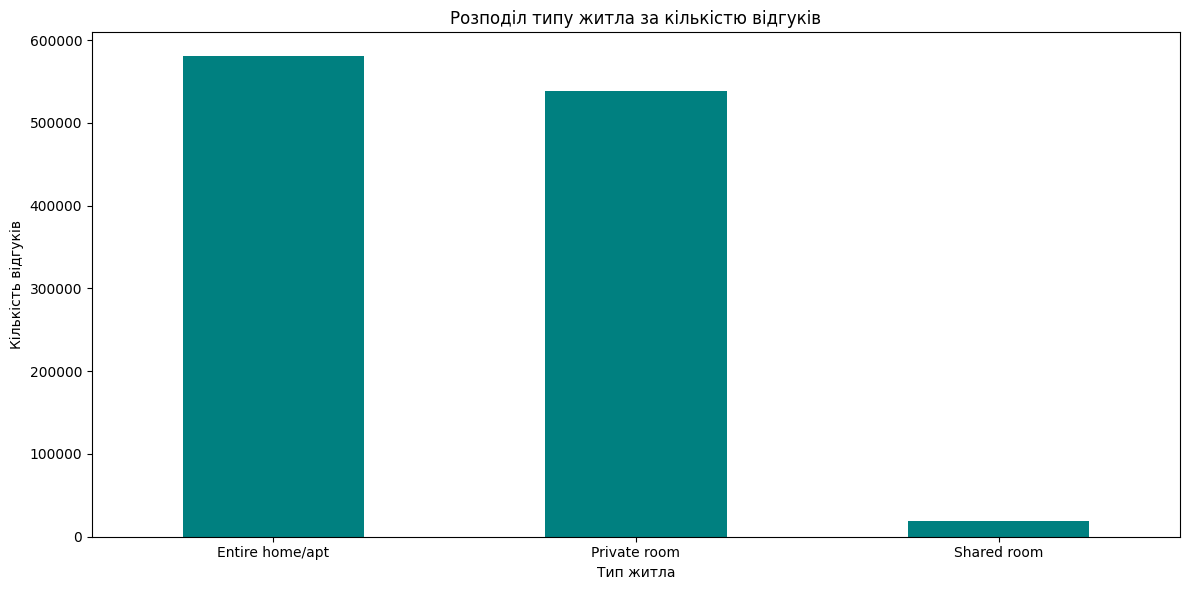

In [36]:
# Візуалізація розподілу
reviews_by_room_type.plot.bar(
    figsize=(12, 6),
    title='Розподіл типу житла за кількістю відгуків',
    xlabel='Тип житла',
    ylabel='Кількість відгуків',
    color='teal',
)

plt.xticks(rotation=360)
plt.tight_layout()

**Висновок:**

Найбільшу кількість відгуків залишають на ціле житло. Від нього зовсім на трохи відстають окремі кімнати. У той же час, спільні кімнати отримують значно меншу увагу. Кількість відгуків на цей тип житла залишається мінімальною. Це може бути зумовлено меншою популярністю таких варіантів і обмеженою кількістю людей, готових обрати їх для оренди.

**11. Розподіл районів за кількістю відгуків** (Орендарі якого з районів найчастіше залишають відгуки?)

In [37]:
reviews_by_neighbourhood_group = df.groupby('neighbourhood_group')['number_of_reviews'].sum()
reviews_by_neighbourhood_group.sort_values(ascending=False)

,number_of_reviews
neighbourhood_group,
Brooklyn,486252
Manhattan,454569
Queens,156950
Bronx,28316
Staten Island,11541


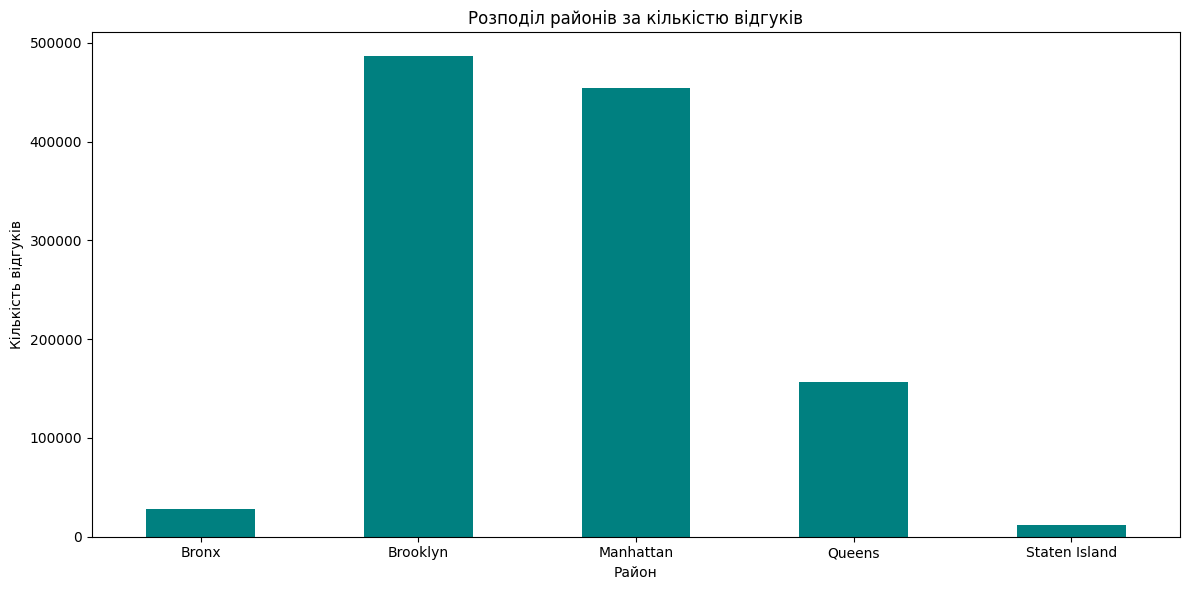

In [38]:
#Візуалізація розподілу
reviews_by_neighbourhood_group.plot.bar(
    figsize=(12, 6),
    title='Розподіл районів за кількістю відгуків',
    xlabel='Район',
    ylabel='Кількість відгуків',
    color='teal',
)

plt.xticks(rotation = 360)
plt.tight_layout()

**Висновок:**

Райони Brooklyn	та Manhattan залишаються найпопулярнішими районами міста. Орендарі з цих районів найчастіше залишають відгуки. Причому Brooklyn у відгуках випередив Manhattan, це можна пояснити більшою активністю у відгуках орендарів з Brooklyn. Майже вполовину менше відгуків залишають орендарі з Queens. Найменше коментарів залишають у районах Bronx та Staten Island, які залишають мінімум відгуків.

**12. Розподіл мікрорайонів за кількістю відгуків** (Орендарі з якого мікрорайону найчастіше залишають відгуки (топ-10)?)

In [39]:
reviews_by_neighbourhood = df.groupby(['neighbourhood_group', 'neighbourhood'])['number_of_reviews'].sum()
reviews_by_neighbourhood.sort_values(ascending=False).head(10)

neighbourhood_group  neighbourhood     
Brooklyn             Bedford-Stuyvesant    110068
                     Williamsburg           85424
Manhattan            Harlem                 75962
Brooklyn             Bushwick               52491
Manhattan            Hell's Kitchen         50227
                     East Village           44670
                     East Harlem            36446
Brooklyn             Crown Heights          36408
Manhattan            Upper West Side        36058
                     Upper East Side        31686
Name: number_of_reviews, dtype: int64

**Висновок:**

Теза про найпопулярніші райони міста за кількістю відгуків - Brooklyn та Manhattan - підтверджується. У топ-10 мікрорайонів за кількістю відгуків знаходяться лише мікрорайони Brooklyn та Manhattan. Найбільшу кількість відгуків залишають орендарі з мікрорайонів Bedford-Stuyvesant та Williamsburg (Brooklyn). Така активність та кількість відгуків з цих мікрорайонів пояснюється їх лідерством у кількісті оголошень для оренди. Загалом перелік топ-10 мікрорайонів за кількістю відгуків збігається з переліком топ-10 мікрорайонів за кількістю оголошень про оренду, за виключенням декількох назв. Звідси слідує логічний висновок, що кількість відгуків має залежність від кількості оголошень оренди.

####Аналіз доступності житла (кількість днів на рік)

**13. Розподіл доступності житла (кількість днів за рік)**

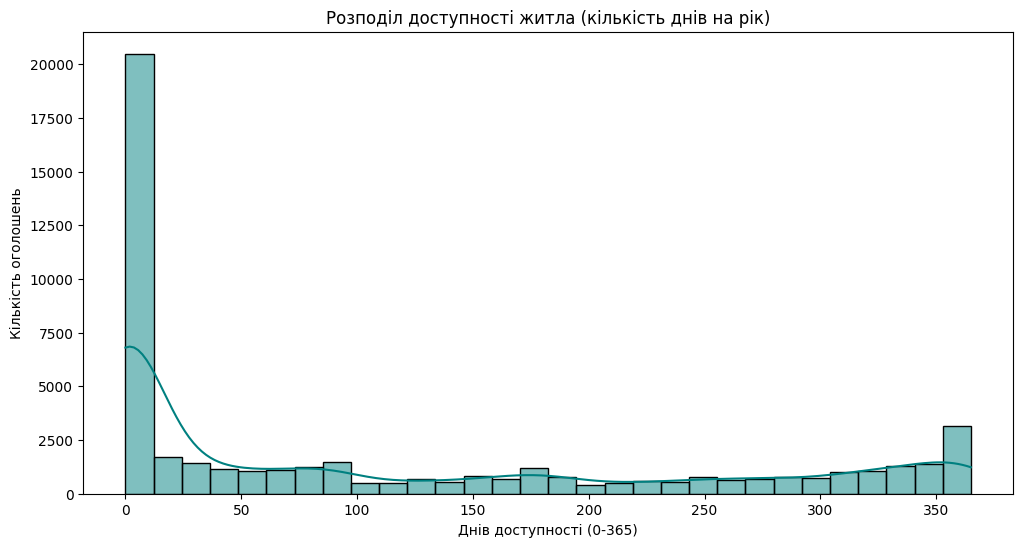

In [40]:
# Візуалізація розподілу
plt.figure(figsize=(12, 6))

sns.histplot(data=df['availability_365'], bins=30, kde=True, color='teal')

plt.title('Розподіл доступності житла (кількість днів на рік)')
plt.xlabel('Днів доступності (0-365)')
plt.ylabel('Кількість оголошень')

plt.show()

На графіку спостерігається великий пік біля значення 0. Що може свідчити про те, що багато оголошень є неактивними, здані на дуже довгий термін або власники просто не оновили календар. Приберемо оголошення з availability_365 == 0, оскільки це неактивні профілі або закриті календарі, і як наслідок ці дані спотворюють реальну картину ринку. Але варто враховувати, що "нульова доступність" не завжди означає саме відсутність житла, часто це може означати його повну заброньованість.

In [41]:
# Фільтр лише активних оголошень
active_df = df[df['availability_365'] > 0]

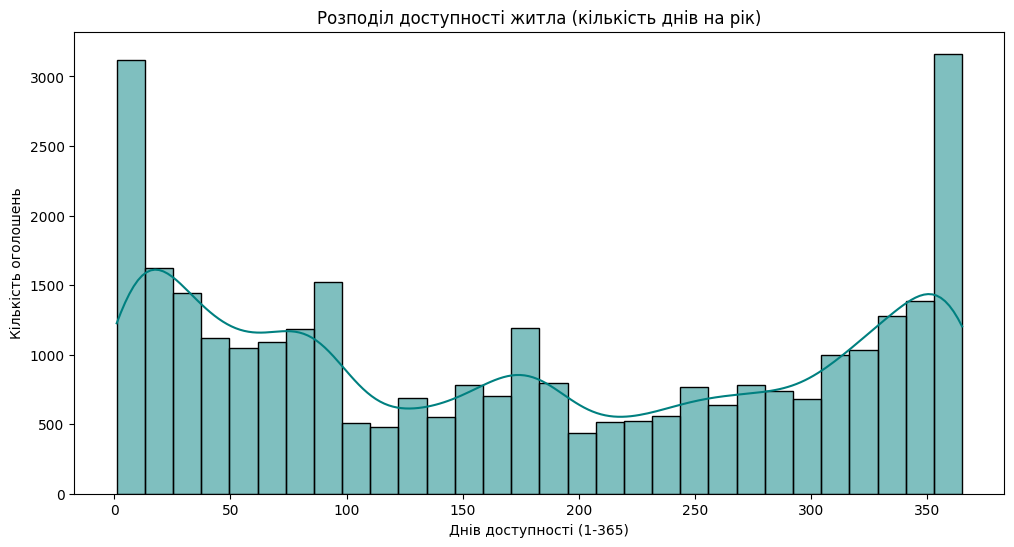

In [42]:
# Візуалізація розподілу
plt.figure(figsize=(12, 6))

sns.histplot(data=active_df['availability_365'], bins=30, kde=True, color='teal')

plt.title('Розподіл доступності житла (кількість днів на рік)')
plt.xlabel('Днів доступності (1-365)')
plt.ylabel('Кількість оголошень')

plt.show()

**Висновок:**

Більшість активних об'єктів доступні для бронювання значну частину року. Це підтверджує, що Airbnb у Нью-Йорку — це не випадковий підробіток, а стабільний бізнес для багатьох власників. Також у великої кількості об'єктів доступність обмежується до 100 днів у році, що може означати або їх велику популярність і як наслідок майже повну заброньованість протягом року, або сезонність цих оголошень. Також з'явився новий пік біля значення 365. Скоріше всього це категорія комерційних оголошень, які доступні протягом всього року.

**14. Розподіл доступності житла за типом** (Який тип житла доступний більшу кількість днів у році?)

In [43]:
availability_by_room_type = active_df.groupby('room_type')['availability_365'].median()
availability_by_room_type.sort_values(ascending=False)

,availability_365
room_type,
Shared room,253.0
Entire home/apt,168.0
Private room,164.0


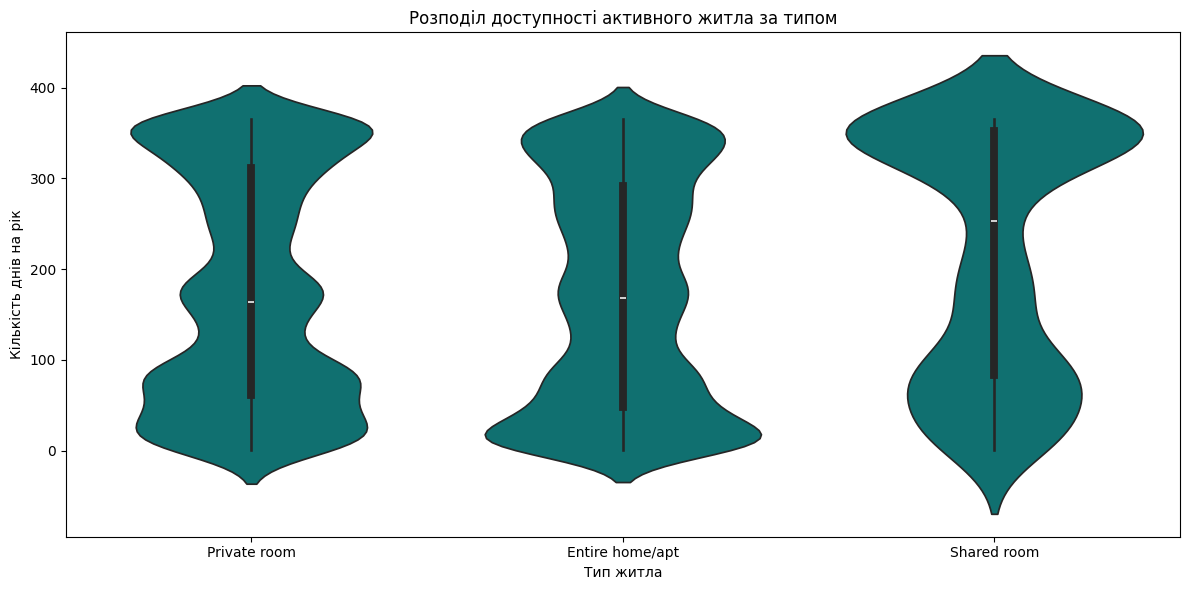

In [44]:
# Візуалізація розподілу
plt.figure(figsize=(12, 6))

sns.violinplot(data=active_df, x='room_type', y='availability_365', color='teal')

plt.title('Розподіл доступності активного житла за типом')
plt.xlabel('Тип житла')
plt.ylabel('Кількість днів на рік')

plt.tight_layout()
plt.show()

*Зауваження:* медіанну доступність житла розраховано за активними оголошеннями, тобто використано датасет active_df. Оскільки оголошення з нульовою доступністю можуть сильно викривити результати.

**Висновок:**

Спільні кімнати є найдоступнішими серед типів житла і найчастіше доступні протягом усього року, це може бути пов'язано з тим, що спільні кімнати найчастіше функціонують як хостели. Цілі будинки/апартаменти та окремі кімнати мають майже однакову медіанну доступність, що може свідчити про схожу модель поведінки їхніх власників на ринку.

**15. Розподіл доступності житла за районом** (В якому районі найбільша доступність житла для оренди?)

In [45]:
availability_by_neighbourhood_group = active_df.groupby('neighbourhood_group')['availability_365'].median()
availability_by_neighbourhood_group.sort_values(ascending=False)

,availability_365
neighbourhood_group,
Staten Island,258.0
Bronx,179.0
Manhattan,177.0
Queens,177.0
Brooklyn,148.0


/tmp/ipykernel_6301/2859934880.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=active_df, x='neighbourhood_group', y='availability_365', palette='viridis')


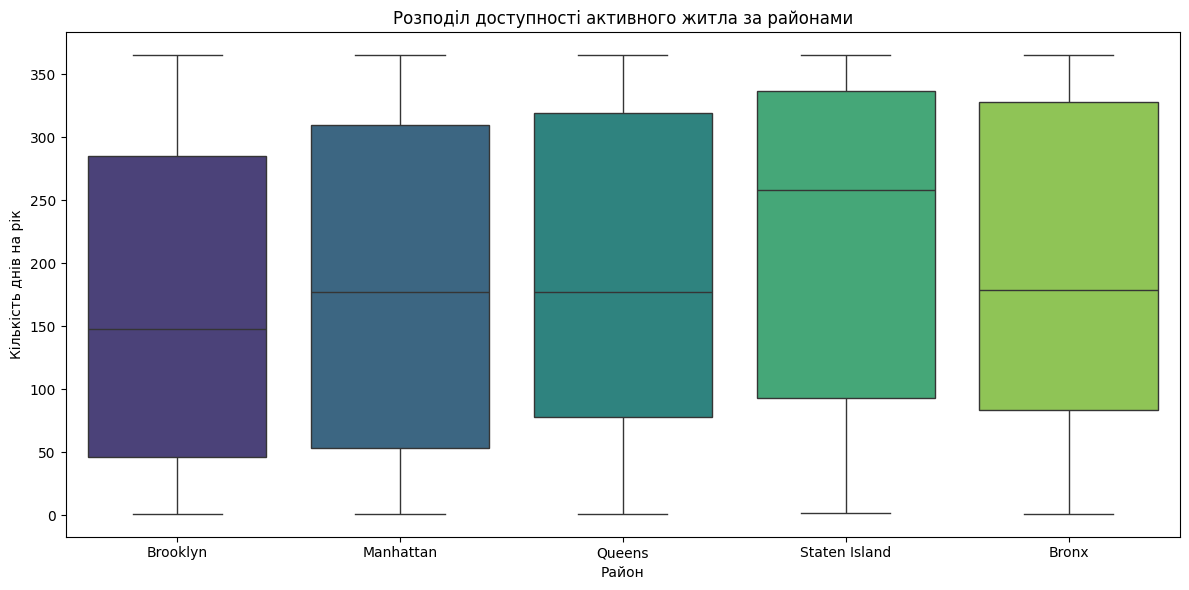

In [46]:
# Візуалізація розподілу
plt.figure(figsize=(12, 6))

sns.boxplot(data=active_df, x='neighbourhood_group', y='availability_365', palette='viridis')

plt.title('Розподіл доступності активного житла за районами')
plt.ylabel('Кількість днів на рік')
plt.xlabel('Район')

plt.tight_layout()
plt.show()

*Зауваження:* медіанну доступність житла розраховано за активними оголошеннями, тобто використано датасет active_df. Оскільки оголошення з нульовою доступністю можуть сильно викривити результати.

**Висновок:**

Найбільш доступним районом є Staten Island, це може бути пов'язано з особливостями його розташування, тому орендарі обирають більш центральні райони з активним культурним і діловим життям. Менш доступними районами є Bronx, Manhattan та Queens, що пов'язано з їх близькістю до центру та до активного життя. Найменш доступний, а отже найбільш популярний район - Brooklyn, що підтверджується кількістю відгуків та оголошень у цьому районі.

**16. Розподіл доступності житла за мікрорайоном** (В якому мікрорайоні найчастіше доступно житло для оренди (топ-10)?)

In [47]:
availability_by_neighbourhood = active_df.groupby(['neighbourhood_group', 'neighbourhood'])['availability_365'].median()
availability_by_neighbourhood.sort_values(ascending=False).head(10)

neighbourhood_group  neighbourhood    
Staten Island        Fort Wadsworth       365.0
Bronx                Co-op City           364.0
Staten Island        Port Richmond        363.0
Bronx                Eastchester          359.0
Staten Island        Willowbrook          351.0
                     Castleton Corners    350.0
Queens               Bellerose            342.5
Staten Island        Randall Manor        340.0
Bronx                Hunts Point          332.5
Brooklyn             Mill Basin           330.5
Name: availability_365, dtype: float64

*Зауваження:* медіанну доступність житла розраховано за активними оголошеннями, тобто використано датасет active_df. Оскільки оголошення з нульовою доступністю можуть сильно викривити результати.

**Висновок:**

Найчастіше серед доступних мікрорайонів зустрічаються мікрорайони Staten Island, що підтверджує попередній висновок про доступність цього району. Також одними з доступних мікрорайонів є мікрорайони Bronx. Також доступними мікрорайонами є Bellerose (Queens) та Mill Basin (Brooklyn). Що показує, що навіть у популярних районах є мікрорайони з доступним для оренди житлом.

####Аналіз кореляції

**17. Кореляція усіх числових значень**

In [48]:
correlation = df.select_dtypes("number").corr()
correlation

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,0.588316,-0.003115,0.090895,0.010639,-0.013229,-0.319800,0.180240,0.133275,0.085468
host_id,0.588316,1.000000,0.020199,0.127022,0.015294,-0.017391,-0.140181,0.209752,0.154949,0.203434
latitude,-0.003115,0.020199,1.000000,0.084830,0.033899,0.024893,-0.015357,-0.018719,0.019518,-0.010942
longitude,0.090895,0.127022,0.084830,1.000000,-0.149954,-0.062772,0.059015,0.138435,-0.114715,0.082669
price,0.010639,0.015294,0.033899,-0.149954,1.000000,0.042805,-0.047926,-0.050531,0.057462,0.081847
minimum_nights,-0.013229,-0.017391,0.024893,-0.062772,0.042805,1.000000,-0.080080,-0.124870,0.127962,0.144275
number_of_reviews,-0.319800,-0.140181,-0.015357,0.059015,-0.047926,-0.080080,1.000000,0.589311,-0.072385,0.171975
reviews_per_month,0.180240,0.209752,-0.018719,0.138435,-0.050531,-0.124870,0.589311,1.000000,-0.047322,0.163664
calculated_host_listings_count,0.133275,0.154949,0.019518,-0.114715,0.057462,0.127962,-0.072385,-0.047322,1.000000,0.225712
availability_365,0.085468,0.203434,-0.010942,0.082669,0.081847,0.144275,0.171975,0.163664,0.225712,1.000000


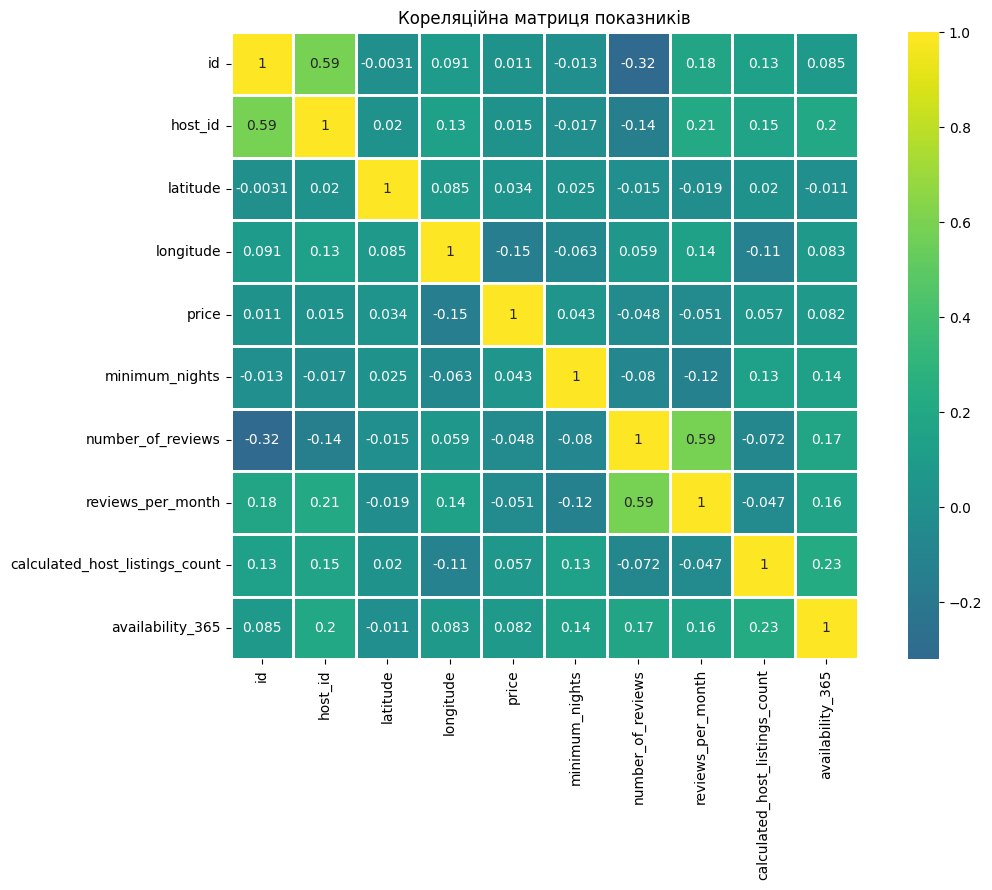

In [49]:
# Візуалізація кореляції
plt.figure(figsize=(12, 9))

sns.heatmap(correlation, annot=True, cmap='viridis', center=0,
            square=True, linewidths=1)

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

**Висновок:**

- Високий коефіцієнт кореляції між id та host_id, а також між number_of_reviews та reviews_per_month є очікуваним і логічним. Зв'язок між id орендодавця та id апартаментів пояснюється тим, що один орендодавець може розміщувати кілька оголошень про оренду. Щодо кількості відгуків, оголошення з більшою кількістю відгуків мають тенденцію до частішого отримання нових відгуків протягом місяця, що може бути наслідком їх популярності.

- Аналіз колонки price свідчить про відсутність сильної лінійної кореляції з іншими числовими показниками, оскільки відповідні коефіцієнти кореляції наближені до нуля, або від'ємні. Це вказує на мінімальний вплив таких факторів, як мінімальна кількість ночей або кількість відгуків на вартість оренди. Натомість особливості розташування житла (район чи мікрорайон), а також тип житла, можуть мати значно більший вплив на формування ціни.

- Від'ємний коефіцієнт кореляції (-0,32) між id та number_of_reviews відображає взаємозв'язок між кількістю відгуків та давністю публікації оголошення. Згідно з цим показником, чим довше оголошення розміщене на платформі, тим більша ймовірність того, що воно має більшу кількість відгуків.

- Позитивний коефіцієнт кореляції (0,23) між показниками calculated_host_listings_count та availability_365 вказує на слабкий рівень залежності доступності житла від кількості оголошень одного орендодавця. Така залежність може бути пояснена тим, що професійні орендодавці, які мають більше активних оголошень, зазвичай забезпечують вищий рівень доступності квартир для оренди.

###Ключові результати дослідження:

На основі комплексного аналізу понад 48 тисяч оголошень було виявлено кілька ключових тенденцій, які характеризують ринок оренди через платформу Airbnb у Нью-Йорку.

- Мангеттен і Бруклін - лідери серед районів. Ці два райони незмінно займають провідні позиції за кількістю доступних пропозицій та активністю користувачів. Хоча в Мангеттені розміщена найбільша кількість оголошень, саме Бруклін має більше відгуків, що говорить про його високу популярність і попит серед мандрівників.

- Основний склад пропозицій на ринку — це цілі апартаменти та приватні кімнати. Найпоширеніший ціновий діапазон оренди коливається між більш дорогим 100 USD - 150 USD за ніч та більш доступним 50 USD - 80 USD за ніч. При цьому ціна оренди значно залежить від району та типу житла, але майже не залежить від таких факторів, як кількість відгуків чи тривалість часу, протягом якого оголошення знаходиться на платформі.

- Значну частку пропозицій контролюють професійні орендодавці, до яких належать агентства та великі гравці ринку. Найбільше таких об’єктів (до 218 оголошень на одного хоста) зосереджено в таких мікрорайонах, як Financial District, де житло доступне для бронювання протягом усього року без сезонних перерв.

- Висока медіанна вартість житла спостерігається не лише в центральних частинах Мангеттена, а й у преміальних локаціях, таких як Fort Wadsworth на Стейтен-Айленді чи Tribeca в Мангеттені. Це підтверджує наявність невеликих нішевих сегментів дорогої нерухомості.

- Найбільший попит на житло в Брукліні робить його менш доступним для бронювання порівняно з іншими районами. Найбільш доступними залишаються об’єкти на Стейтен-Айленді, а також спільні кімнати (shared rooms), що функціонують за принципом хостелів.

- Кількість отриманих відгуків прямо пропорційно залежить від популярності оголошення та його терміну присутності на платформі. Об'єкти з вже накопиченою репутацією продовжують активніше залучати нові відгуки, що позитивно позначається на їхній конкурентоспроможності.

*Загальний висновок.* Ринок оренди житла через Airbnb у Нью-Йорку добре розвинений, але неоднорідний. Для успішного виходу на цей ринок чи інвестування важливо враховувати особливості кожного конкретного мікрорайону та типу апартаментів, оскільки саме розташування та тип житла має визначальний вплив на рівень попиту та ціну оренди.

###Дашборд

На дашборді представлено такі ключові показники: загальна кількість оголошень, орендодавців і відгуків. Крім того, візуалізовано графіки розподілу за кількома критеріями. Зокрема, відображено розподіл житла за районами та типом житла, а також аналіз цін залежно від району та типу житла з урахуванням аномальних значень (викидів). Також проаналізовано кількість відгуків, розподілених за районами та типами житла (у вигляді загальної суми), доступність житла в розрізі районів і типів (визначена через медіану), а також загальну доступність житла, виміряну за кількістю днів на рік. Усі пропущені значення у датасеті були попередньо заповнені, а записи з ціною, що дорівнює нулю, видалено для забезпечення актуальності даних.

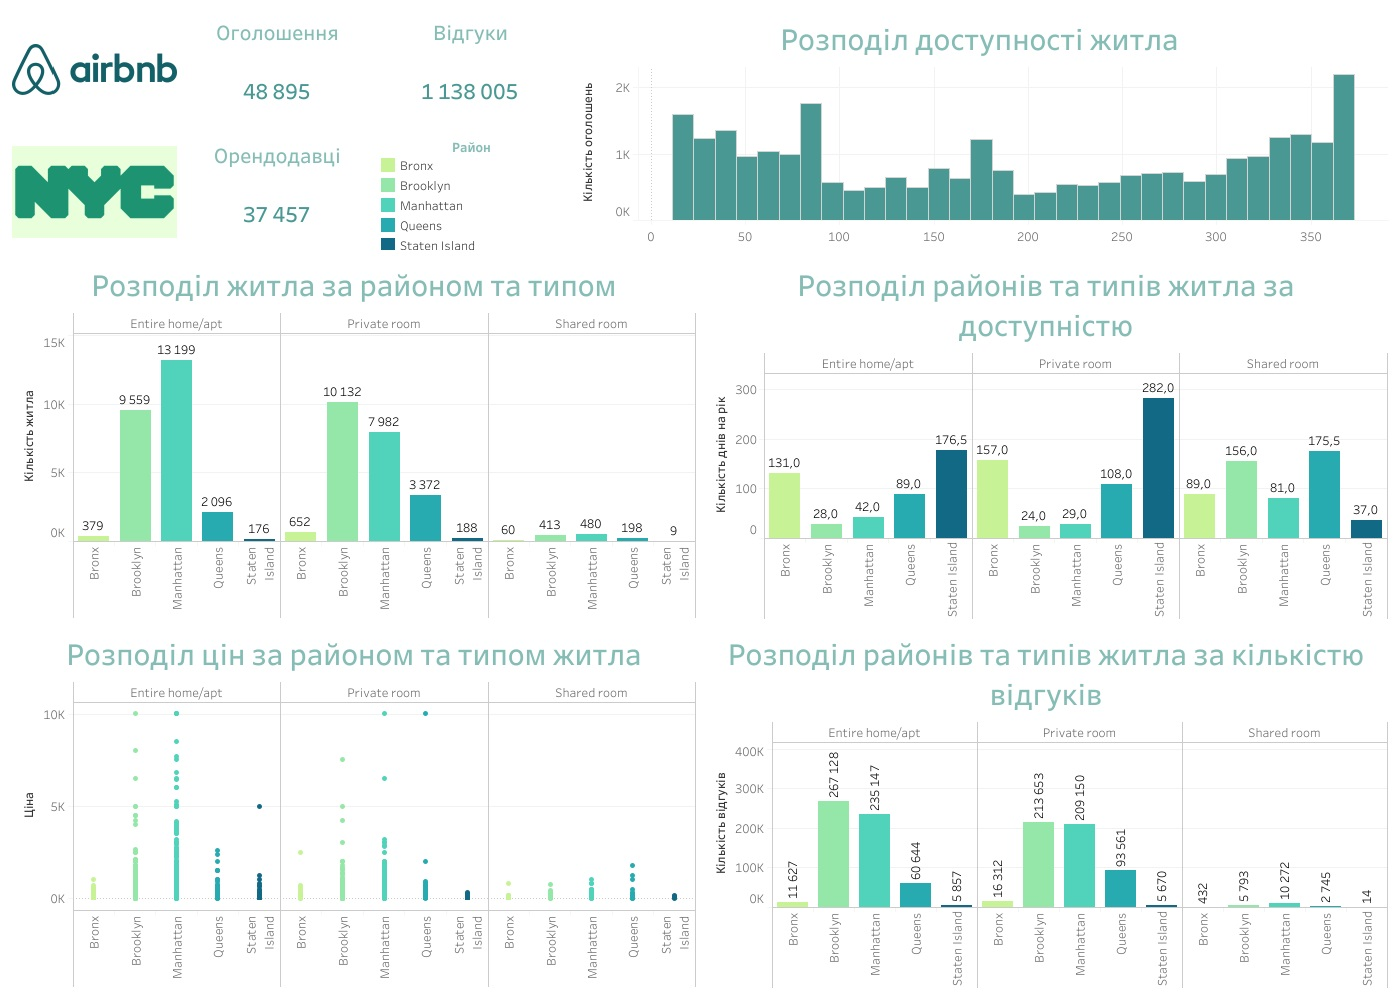

**Посилання на дашборд**

https://public.tableau.com/app/profile/a.a8255/viz/AirbnbNYC2019public/Dashboard

На дашборді представлені ті ж самі показники, що й на попередньому, але з використанням очищених даних. Окрім уже виконаного заповнення пропущених даних і видалення записів із ціною, що дорівнює нулю (застосованих до попередньої версії дашборду), додатково було видалено аномальні значення (викиди) та оголошення, які вказували на відсутність активності (availability_365 == 0).

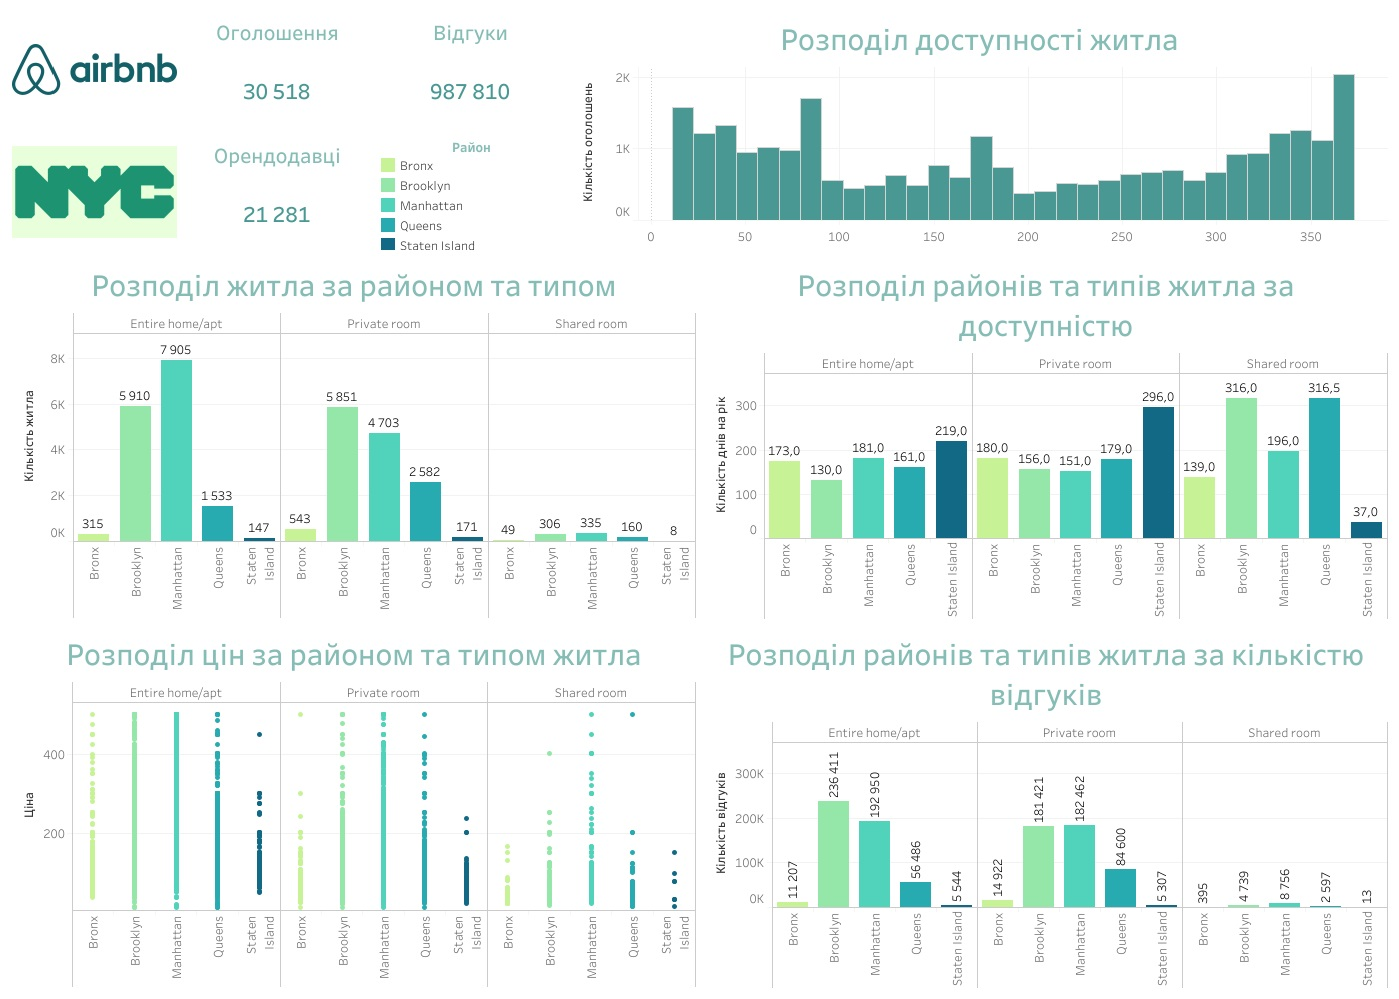

**Посилання на дашборд з очищеними даними:**

https://public.tableau.com/app/profile/a.a8255/viz/AirbnbNYC2019cleandatapublic/Dashboard